# Introducción a la Ciencia de Datos con Python




# Introducción a pandas con el dataset Iris

## Objetivo
Aprender las principales funcionalidades de **pandas** para manipulación y análisis de datos utilizando el dataset Iris, incorporando también **NumPy** para operaciones numéricas y **matplotlib / seaborn** para visualización.


El dataset de Iris es uno de los conjuntos de datos más conocidos en ciencia de datos y aprendizaje automático, introducido por el estadístico Ronald Fisher en 1936. Contiene 150 observaciones de flores pertenecientes a tres especies distintas de iris: setosa, versicolor y virginica.

Para cada flor se registran cuatro características numéricas: la longitud y el ancho del sépalo, y la longitud y el ancho del pétalo (medidas en centímetros). Este dataset se utiliza habitualmente como ejemplo introductorio para tareas de análisis exploratorio de datos, visualización y clasificación, ya que es sencillo, está limpio y permite identificar patrones claros entre las distintas especies.

In [ ]:
# Instalación de libs
%pip install pandas
%pip install numpy 
%pip install matplotlib
%pip install seaborn
%pip install -U scikit-learn

In [1]:
# Libs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [2]:
import pandas as pd
from sklearn.datasets import load_iris

iris_raw = load_iris(as_frame=True)
df = iris_raw.frame.copy()

df["species"] = df["target"].map(dict(enumerate(iris_raw.target_names)))
df = df.drop(columns=["target"])

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 1. Primer contacto con el DataFrame

### Ejercicios
- Mostrar las primeras 5 filas.
- Mostrar las últimas 5 filas.
- Consultar la forma del dataframe.
- Ver los nombres de las columnas.
- Identificar el tipo de dato de cada columna.
- Obtener un resumen con `info()`.
- Obtener estadísticas con `describe()`.

In [ ]:
# Primeras 5 filas
df.head()

# Últimas 5 filas
df.tail()

# Dimensiones
df.shape

# Nombres de columnas
df.columns

# Tipos de datos
df.dtypes

# Información general
df.info()

# Resumen estadístico
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. Selección de columnas y filas

### Ejercicios
- Seleccionar una columna.
- Seleccionar varias columnas.
- Mostrar una fila concreta.
- Mostrar un rango de filas.
- Usar `loc`.
- Usar `iloc`.

In [5]:
# Usar loc
df.loc[10:15, ["sepal length (cm)", "species"]]

,sepal length (cm),species
10,5.4,setosa
11,4.8,setosa
12,4.8,setosa
13,4.3,setosa
14,5.8,setosa
15,5.7,setosa


In [6]:
# Usar iloc
df.iloc[10:16, [0, 4]]

,sepal length (cm),species
10,5.4,setosa
11,4.8,setosa
12,4.8,setosa
13,4.3,setosa
14,5.8,setosa
15,5.7,setosa


In [ ]:
# Seleccionar una columna
df["sepal length (cm)"]

# Seleccionar varias columnas
df[["sepal length (cm)", "sepal width (cm)"]]

# Mostrar una fila concreta
df.iloc[10]

# Mostrar un rango de filas
df.iloc[10:21]




,sepal length (cm),species
10,5.4,setosa
11,4.8,setosa
12,4.8,setosa
13,4.3,setosa
14,5.8,setosa
15,5.7,setosa


## 3. Filtrado de datos

### Ejercicios
- Filtrar por condiciones numéricas.
- Filtrar por especie.
- Combinar condiciones.
- Usar `isin()`.
- Usar `query()`.


In [7]:
# Pétalo con longitud mayor que 5
df[df["petal length (cm)"] > 5]

# Solo setosa
df[df["species"] == "setosa"]

# Versicolor con ancho del pétalo mayor que 1.3
df[(df["species"] == "versicolor") & (df["petal width (cm)"] > 1.3)]

# Dos especies con isin
df[df["species"].isin(["setosa", "virginica"])]

# Usar query
df.query("`petal length (cm)` > 5 and species == 'virginica'")

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
100,6.3,3.3,6.0,2.5,virginica
101,5.8,2.7,5.1,1.9,virginica
102,7.1,3.0,5.9,2.1,virginica
103,6.3,2.9,5.6,1.8,virginica
104,6.5,3.0,5.8,2.2,virginica
105,7.6,3.0,6.6,2.1,virginica
107,7.3,2.9,6.3,1.8,virginica
108,6.7,2.5,5.8,1.8,virginica
109,7.2,3.6,6.1,2.5,virginica
110,6.5,3.2,5.1,2.0,virginica


## 4. Ordenación y ranking

### Ejercicios
- Ordenar por una columna.
- Ordenar descendente.
- Obtener mayores valores.
- Obtener menores valores.
- Identificar máximos y mínimos.

In [ ]:
# Ordenar por longitud del sépalo
df.sort_values("sepal length (cm)")

# Ordenar de mayor a menor por ancho del pétalo
df.sort_values("petal width (cm)", ascending=False)

# 10 mayores valores de longitud de pétalo
df.nlargest(10, "petal length (cm)")

# 10 menores valores de longitud de pétalo
df.nsmallest(10, "petal length (cm)")

# Índice del máximo y mínimo
max_idx = df["sepal length (cm)"].idxmax()
min_idx = df["petal width (cm)"].idxmin()

# Filas correspondientes
df.loc[max_idx]
df.loc[min_idx]

In [15]:

# 10 mayores valores de longitud de pétalo
df.nlargest(10, "petal length (cm)")

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,petal_ratio,petal_area_aprox,petal_long,petal_long_text,sepal_size,petal_size_np
118,7.7,2.6,6.9,2.3,virginica,3.000000,15.87,True,Sí,grande,largo
117,7.7,3.8,6.7,2.2,virginica,3.045455,14.74,True,Sí,grande,largo
122,7.7,2.8,6.7,2.0,virginica,3.350000,13.40,True,Sí,grande,largo
105,7.6,3.0,6.6,2.1,virginica,3.142857,13.86,True,Sí,grande,largo
131,7.9,3.8,6.4,2.0,virginica,3.200000,12.80,True,Sí,grande,largo
107,7.3,2.9,6.3,1.8,virginica,3.500000,11.34,True,Sí,grande,largo
109,7.2,3.6,6.1,2.5,virginica,2.440000,15.25,True,Sí,grande,largo
130,7.4,2.8,6.1,1.9,virginica,3.210526,11.59,True,Sí,grande,largo
135,7.7,3.0,6.1,2.3,virginica,2.652174,14.03,True,Sí,grande,largo
100,6.3,3.3,6.0,2.5,virginica,2.400000,15.00,True,Sí,mediano,largo


## 5. Estadística descriptiva con pandas y NumPy

### Ejercicios
- Calcular media, mediana y desviación.
- Calcular mínimo y máximo.
- Calcular percentiles.
- Analizar variabilidad.
- Repetir algunos cálculos con NumPy.

In [ ]:
# Con pandas
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.std(numeric_only=True)
df.min(numeric_only=True)
df.max(numeric_only=True)
df.quantile([0.25, 0.5, 0.75], numeric_only=True)

# Rango con pandas 
rango = df.max(numeric_only=True) - df.min(numeric_only=True)
rango

# Con NumPy sobre una variable
petal_length = df["petal length (cm)"].to_numpy()

np.mean(petal_length)
np.median(petal_length)
np.std(petal_length)
np.min(petal_length)
np.max(petal_length)
np.percentile(petal_length, [25, 50, 75])

## 6. Análisis por grupos

### Ejercicios
- Contar elementos por especie.
- Calcular medias por grupo.
- Calcular varias métricas con `agg()`.
- Ordenar resultados.

In [ ]:
# Número de flores por especie
df.groupby("species").size()

# Medias por especie
df.groupby("species").mean(numeric_only=True)

# Varias métricas
df.groupby("species").agg({
    "sepal length (cm)": ["mean", "min", "max"],
    "petal length (cm)": ["mean", "std"],
    "petal width (cm)": ["mean", "max"]
})

# Ordenar especies por longitud media del pétalo
df.groupby("species").mean(numeric_only=True).sort_values("petal length (cm)")

## 7. Creación y transformación de columnas con pandas y NumPy

### Ejercicios
- Crear nuevas columnas.
- Generar ratios.
- Crear variables booleanas.
- Transformar valores con `map`.
- Crear categorías con `cut`.
- Usar `np.where()` para crear variables condicionales.

In [8]:
# Ratio largo/ancho del pétalo
df["petal_ratio"] = df["petal length (cm)"] / df["petal width (cm)"]

# Área aproximada del pétalo
df["petal_area_aprox"] = df["petal length (cm)"] * df["petal width (cm)"]

# Variable booleana
df["petal_long"] = df["petal length (cm)"] > 4

# Convertir booleano a texto
df["petal_long_text"] = df["petal_long"].map({True: "Sí", False: "No"})

# Categorías de tamaño de sépalo
df["sepal_size"] = pd.cut(
    df["sepal length (cm)"],
    bins=[0, 5.5, 6.5, 10],
    labels=["pequeño", "mediano", "grande"]
)

# Crear columna con NumPy
df["petal_size_np"] = np.where(
    df["petal length (cm)"] > 4,
    "largo",
    "corto"
)

# Ver resultado
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,petal_ratio,petal_area_aprox,petal_long,petal_long_text,sepal_size,petal_size_np
0,5.1,3.5,1.4,0.2,setosa,7.0,0.28,False,No,pequeño,corto
1,4.9,3.0,1.4,0.2,setosa,7.0,0.28,False,No,pequeño,corto
2,4.7,3.2,1.3,0.2,setosa,6.5,0.26,False,No,pequeño,corto
3,4.6,3.1,1.5,0.2,setosa,7.5,0.30,False,No,pequeño,corto
4,5.0,3.6,1.4,0.2,setosa,7.0,0.28,False,No,pequeño,corto


## 8. Conteos y frecuencias

### Ejercicios
- Contar valores categóricos.
- Obtener proporciones.
- Crear tablas cruzadas.

In [ ]:
# Frecuencia absoluta de especies
df["species"].value_counts()

# Frecuencia relativa
df["species"].value_counts(normalize=True)

# Frecuencia de la variable petal_long
df["petal_long"].value_counts()

# Tabla cruzada
pd.crosstab(df["species"], df["petal_long"])

In [18]:
# Frecuencia de la variable petal_long
df["petal_long"].value_counts()

petal_long
True     84
False    66
Name: count, dtype: int64

In [17]:
# Frecuencia relativa
df["species"].value_counts(normalize=True)

species
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64

In [16]:
# Frecuencia absoluta de especies
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 9. Tratamiento de nulos

### Ejercicios
- Detectar valores nulos.
- Contarlos.
- Rellenarlos.
- Eliminarlos.

In [9]:
# Comprobar nulos
df.isna().sum()

# Crear una copia para simular nulos
df_null = df.copy()
df_null.loc[[1, 5, 10], "sepal length (cm)"] = None

# Contar nulos
df_null.isna().sum()

# Rellenar con la media
df_filled = df_null.copy()
df_filled["sepal length (cm)"] = df_filled["sepal length (cm)"] .fillna(
    df_filled["sepal length (cm)"].mean()
)

# Eliminar filas con nulos
df_dropped = df_null.dropna()

# Ver tamaños
print(df_null.shape)
print(df_filled.shape)
print(df_dropped.shape)

(150, 11)
(150, 11)
(147, 11)


## 10. Manipulación estructural

### Ejercicios
- Renombrar columnas.
"sepal length (cm)": "sepal_length",
"sepal width (cm)": "sepal_width",
"petal length (cm)": "petal_length",
"petal width (cm)": "petal_width"

- Eliminar columnas. -- Alguna de las que creamos antes
- Reordenar columnas.
- Cambiar índices.

In [10]:
# Renombrar columnas
df_renamed = df.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width"
})



# Eliminar columna temporal
df_drop = df.drop(columns=["petal_long_text"])

# Reordenar columnas
new_order = [
    "species", "sepal length (cm)", "sepal width (cm)",
    "petal length (cm)", "petal width (cm)",
    "petal_ratio", "petal_area_aprox", "petal_long", "sepal_size", "petal_size_np"
]
df_reordered = df[new_order]

# Cambiar índice
df_indexed = df.set_index("species")
df_indexed
# # Restaurar índice
# df_reset = df_indexed.reset_index()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),petal_ratio,petal_area_aprox,petal_long,petal_long_text,sepal_size,petal_size_np
species,,,,,,,,,,
setosa,5.1,3.5,1.4,0.2,7.000000,0.28,False,No,pequeño,corto
setosa,4.9,3.0,1.4,0.2,7.000000,0.28,False,No,pequeño,corto
setosa,4.7,3.2,1.3,0.2,6.500000,0.26,False,No,pequeño,corto
setosa,4.6,3.1,1.5,0.2,7.500000,0.30,False,No,pequeño,corto
setosa,5.0,3.6,1.4,0.2,7.000000,0.28,False,No,pequeño,corto
...,...,...,...,...,...,...,...,...,...,...
virginica,6.7,3.0,5.2,2.3,2.260870,11.96,True,Sí,grande,largo
virginica,6.3,2.5,5.0,1.9,2.631579,9.50,True,Sí,mediano,largo
virginica,6.5,3.0,5.2,2.0,2.600000,10.40,True,Sí,mediano,largo


## 11. Duplicados y unicidad

### Ejercicios
- Detectar duplicados.
- Eliminarlos.
- Contar valores únicos.

In [11]:
# Detectar duplicados
df.duplicated().sum()

# Añadir un duplicado artificial
df_dup = pd.concat([df, df.iloc[[0]]], ignore_index=True)

# Comprobar duplicados
df_dup.duplicated().sum()

# Eliminar duplicados
df_no_dup = df_dup.drop_duplicates()

# Valores únicos
df["species"].unique()

# Número de valores únicos
df["species"].nunique()

3

## 12. Correlaciones con apoyo visual

### Ejercicios
- Calcular matriz de correlación.
- Analizar relaciones entre variables.
- Representar la correlación con un mapa de calor.

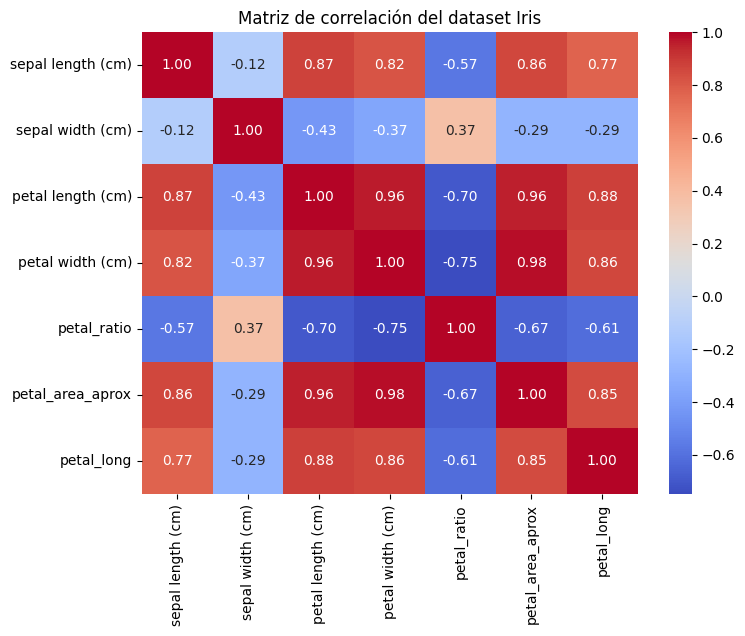

In [12]:
# Matriz de correlación
corr = df.corr(numeric_only=True)
corr

# Heatmap con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación del dataset Iris")
plt.show()

## 13. Tablas resumen

### Ejercicios
- Crear tablas agregadas.
- Redondear resultados.
- Exportar a CSV.


In [19]:
# Tabla resumen por especie
summary = df.groupby("species").agg({
    "sepal length (cm)": ["mean", "std"],
    "sepal width (cm)": ["mean", "std"],
    "petal length (cm)": ["mean", "std"],
    "petal width (cm)": ["mean", "std"]
}).round(2)

summary

# Exportar a CSV
summary.to_csv("iris_summary.csv")

In [20]:
summary

sepal length (cm)       sepal width (cm)       petal length (cm)  \
                        mean   std             mean   std              mean   
species                                                                       
setosa                  5.01  0.35             3.43  0.38              1.46   
versicolor              5.94  0.52             2.77  0.31              4.26   
virginica               6.59  0.64             2.97  0.32              5.55   

                 petal width (cm)        
             std             mean   std  
species                                  
setosa      0.17             0.25  0.11  
versicolor  0.47             1.33  0.20  
virginica   0.55             2.03  0.27

## 14. Visualización básica con matplotlib y seaborn

### Ejercicios
- Crear un histograma.
- Crear un boxplot por especie.
- Crear un scatter plot.
- Comparar distribuciones con seaborn.

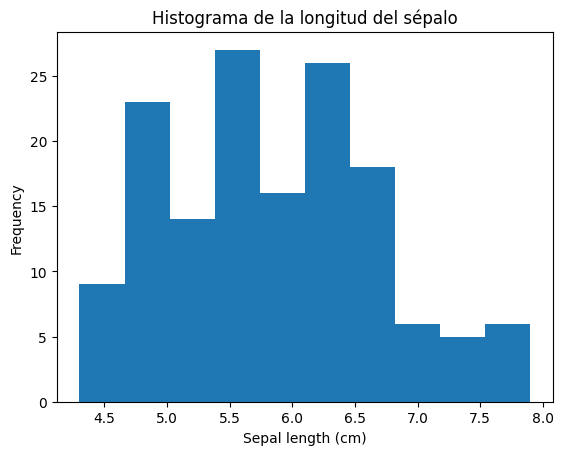

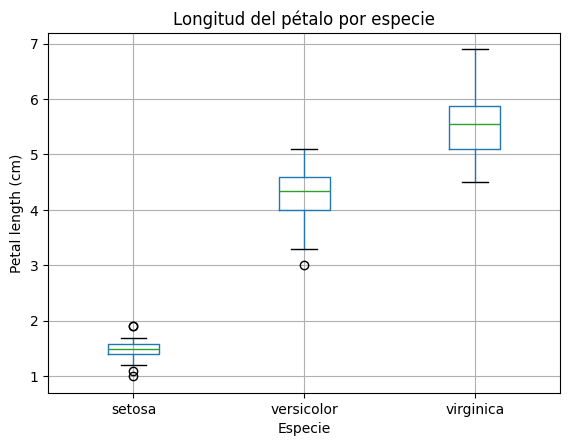

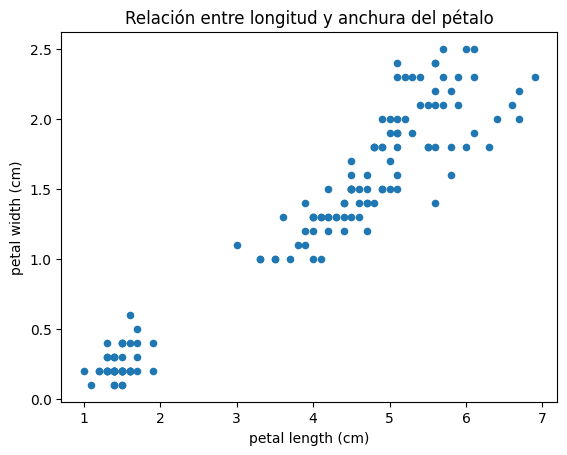

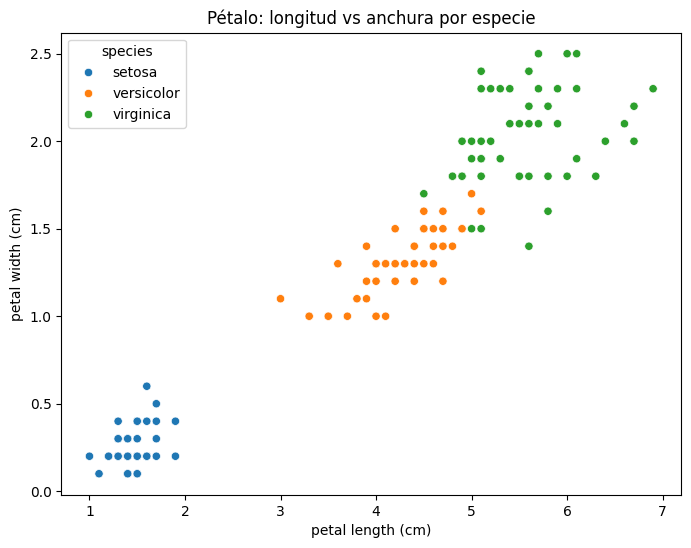

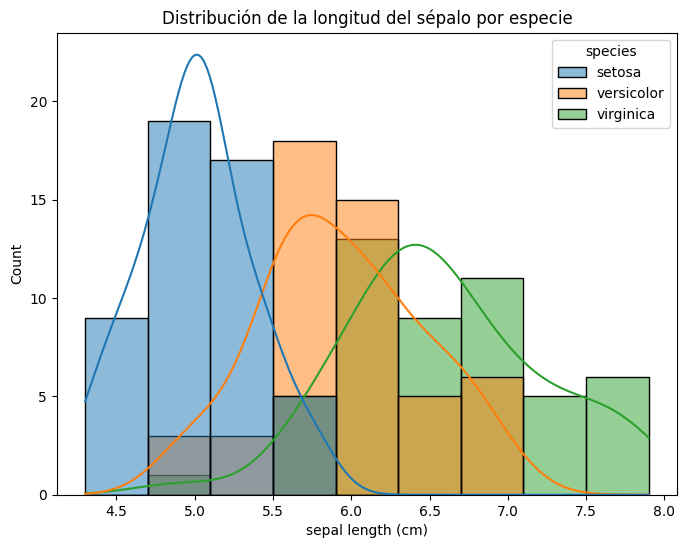

In [14]:
# Histograma con pandas + matplotlib
df["sepal length (cm)"].plot.hist()
plt.title("Histograma de la longitud del sépalo")
plt.xlabel("Sepal length (cm)")
plt.show()

# Boxplot con pandas + matplotlib
df.boxplot(column="petal length (cm)", by="species")
plt.title("Longitud del pétalo por especie")
plt.suptitle("")
plt.xlabel("Especie")
plt.ylabel("Petal length (cm)")
plt.show()

# Scatter plot con pandas + matplotlib
df.plot.scatter(x="petal length (cm)", y="petal width (cm)")
plt.title("Relación entre longitud y anchura del pétalo")
plt.show()

# Scatter plot con seaborn y color por especie
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)", hue="species")
plt.title("Pétalo: longitud vs anchura por especie")
plt.show()

# Histograma con seaborn
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x="sepal length (cm)", hue="species", kde=True)
plt.title("Distribución de la longitud del sépalo por especie")
plt.show()

## 15. Ejercicio extra con NumPy: estandarización manual

### Objetivo
Mostrar un uso adicional de NumPy en preprocesamiento de datos.

### Ejercicio
Estandarizar manualmente la variable `petal length (cm)` restando la media y dividiendo por la desviación típica.

In [ ]:
petal_length = df["petal length (cm)"].to_numpy()

petal_length_std = (petal_length - np.mean(petal_length)) / np.std(petal_length)

petal_length_std[:10]

## 16. Ejercicio extra con Seaborn: pairplot

### Objetivo
Visualizar muchas relaciones a la vez.

### Ejercicio
Crear un `pairplot` para observar cómo se separan las especies en función de todas las variables numéricas.

In [ ]:
sns.pairplot(df, hue="species")
plt.show()

## 17. Mini proyecto final

### Enunciado
Responder:
- ¿Qué especie tiene pétalos más grandes?
- ¿Cuál tiene mayor variabilidad?
- ¿Se distinguen las especies por pétalos?
- ¿Qué gráfico ayuda mejor a justificar la respuesta?


In [ ]:
# Especie con mayor tamaño medio de pétalo
df.groupby("species")[["petal length (cm)", "petal width (cm)", "petal_area_aprox"]].mean()

# Variabilidad en ancho del sépalo
df.groupby("species")["sepal width (cm)"].std().sort_values(ascending=False)

# Resumen final
final_summary = df.groupby("species").agg({
    "sepal length (cm)": ["mean", "std"],
    "sepal width (cm)": ["mean", "std"],
    "petal length (cm)": ["mean", "std"],
    "petal width (cm)": ["mean", "std"],
    "petal_area_aprox": ["mean", "max"]
}).round(2)

final_summary

# Gráfico de apoyo
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)", hue="species")
plt.title("Separación de especies usando variables del pétalo")
plt.show()

### Interpretación final
- `virginica` suele presentar los pétalos más grandes.
- La variabilidad puede compararse observando la desviación típica por especie.
- Las variables del pétalo suelen separar bastante bien las especies, especialmente `setosa` frente a las demás.
- El gráfico de dispersión y el `pairplot` ayudan mucho a justificar visualmente estas conclusiones.